In [1]:
import gdsfactory as gf
gf.gpdk.PDK.activate()

In [2]:
from upvfab.sin300.cband import PDK, cells

Objective: Finalize the full die layout with test structures for fabrication.
Steps:
1. Integrate the wvl tracker layout with input/output connections.
2. Add test structures (e.g., waveguides, and mmis)
to enable characterization of the filter.
3. Export the final .GDS file for submission and verification

In [3]:
wgw = 0.5
dieL = 5000
dieW = 5000
border = 125
layer_wg = "WG"
layer_box = "FLOORPLAN"

# Die specifications (Chip)
box = gf.Component()

obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
box = gf.boolean(A=obox, B=ibox, operation="A-B", layer="FLOORPLAN")

# Adding ports to a component 
box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)

gf.clear_cache()

@gf.cell
def die(dieL = 5000, dieW = 5000, border = 250, layer_box = "FLOORPLAN"):
    # Die specifications (Chip)
    box = gf.Component()
    obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
    box = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    # Adding ports to a component 
    box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)
    box.draw_ports()
    return box

In [4]:
main = gf.Component()
die_ref = main << die(dieW = dieW, layer_box = "FLOORPLAN")

## DEFINICIÓN MMI3X3: basado en definición 2x2 gds


    Schematic:

                    length_mmi
                     <------>
                     ________
                  __/        \__  o4
             o3  __          __
                   \        /
                  __/        \__  o5
             o2  __          __
                   \        /
                  __/        \__  o6
             o1  __          __
                   \________/

In [5]:
from gdsfactory.component import Component
from gdsfactory.typings import CrossSectionSpec, ComponentSpec


@gf.cell
def mmi3x3(
    width: float | None = None,
    width_taper: float = 1.0,
    length_taper: float = 10.0,
    length_mmi: float = 20.0,
    width_mmi: float = 6.0,
    gap_mmi: float = 0.25,
    taper: ComponentSpec = gf.components.taper,
    straight: ComponentSpec = gf.components.straight,
    cross_section: CrossSectionSpec = "strip",
) -> Component:
    c = gf.Component()

    gap_mmi = gf.snap.snap_to_grid(gap_mmi, grid_factor=2) #ajusta el gap a la rejilla para evitar decimales raros que queden fuera del grid

    x = gf.get_cross_section(cross_section)
    width = width or x.width
    w_taper = width_taper

    _taper = gf.get_component(
        taper,
        length=length_taper,
        width1=width,
        width2=w_taper,
        cross_section=cross_section,
    )

    pitch = w_taper + gap_mmi

    y_bot = -pitch
    y_mid = 0
    y_top = +pitch

    _ = c << gf.get_component(
        straight,
        length=length_mmi,
        width=width_mmi,
        cross_section=cross_section,
    )

    temp_component = Component() #para definir los puertos ideales (temporales)

    ports = [
        temp_component.add_port(
            name="o1",
            orientation=180,
            center=(0, y_bot),
            width=w_taper,
            cross_section=x,
        ),
        temp_component.add_port(
            name="o2",
            orientation=180,
            center=(0, y_mid),
            width=w_taper,
            cross_section=x,
        ),
        temp_component.add_port(
            name="o3",
            orientation=180,
            center=(0, y_top),
            width=w_taper,
            cross_section=x,
        ),
        temp_component.add_port(
            name="o4",
            orientation=0,
            center=(length_mmi, y_top),
            width=w_taper,
            cross_section=x,
        ),
        temp_component.add_port(
            name="o5",
            orientation=0,
            center=(length_mmi, y_mid),
            width=w_taper,
            cross_section=x,
        ),
        temp_component.add_port(
            name="o6",
            orientation=0,
            center=(length_mmi, y_bot),
            width=w_taper,
            cross_section=x,
        ),
    ]

    for port in ports:
        taper_ref = c << _taper
        taper_ref.connect(
            port="o2",
            other=port,
            allow_width_mismatch=True,
        )
        c.add_port(name=port.name, port=taper_ref.ports["o1"])

    c.flatten()
    return c

2026-05-09 12:02:22.518 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/pic-upv-lab5-finalproject/build/oas/1976774129.oas'


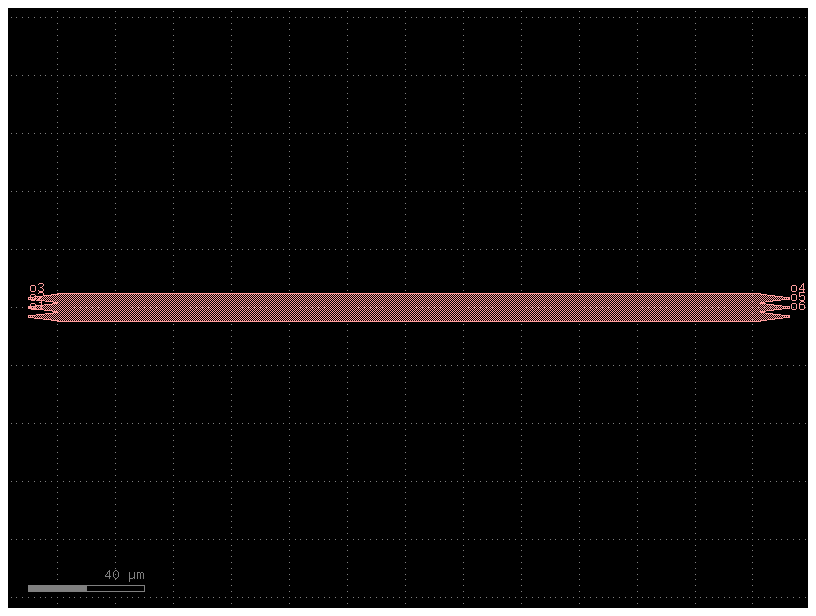

In [6]:
c = mmi3x3(width= 0.45, width_taper=2.9, length_taper= 10.0, length_mmi = 242.4723, width_mmi= 10, gap_mmi = 0.25)
c.draw_ports()
c.show()
c.plot()

## ESPIRAL: 

In [7]:
"""
Spirals for cutback prop.loss measurement
DoE: Assuming 1dB/cm loss: 1.5cm difference between spirals mean 1.5dB difference between
measurements.
"""
from upvfab.sin300.cband.cells import define_spiral_length
rad = 120
N_spr = 10
dy_spr = 10
target_length = 56000  # in microns 
#target_length = 56032.624

dx_length_spiral = define_spiral_length(delay_length=target_length,
                                        N_spr=N_spr, #N_spr: order-number of loops (0,1,...)
                                        radius=rad, 
                                        d_SPR=10, #d_SPR: waveguide separation
                                        dy_SPR=dy_spr,#dy_SPR: spiral straight extent in y
                                        )

spiral = cells.spiral_upv(
        radius=rad,
        N_spr=N_spr,
        d_SPR = 10,
        dy_SPR = dy_spr,
        dx_SPR = dx_length_spiral,
        layer="strip",
        )
print('Spiral length', spiral.info["length"])


Defining spiral length for delay: 56000


TypeError: float() argument must be a string or a real number, not 'Path'

["Port(self.name='o1', self.width=500, trans=r180 *1 40,1040.7, layer=WG (1/0), port_type=optical)", "Port(self.name='o2', self.width=500, trans=r0 *1 2321.4,1040.7, layer=WG (1/0), port_type=optical)"]


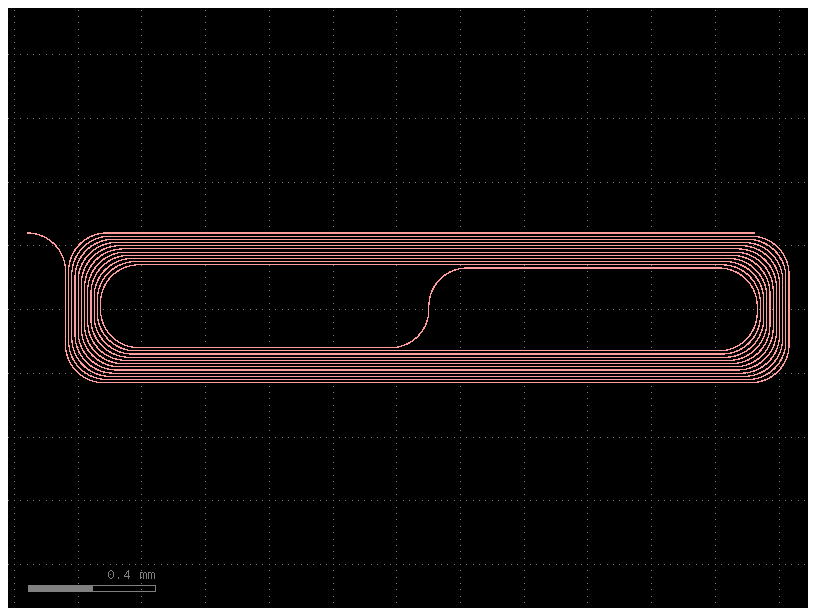

In [ ]:
#DEBO CAMBIAR LA WIDTH DE LA ESPIRAL A 0.45 UM, AHORA ESTÁ EN 0.5 UM
spiral.plot()
print(spiral.ports)

## CIRCUITO

In [8]:
def wvl_tracker(length_mmi_2x2: float = 242.4723, length_mmi_3x3: float =  242.4723, AL: float = 56000): 
    c = gf.Component()
    mmi_95 = c << cells.mmi2x2(0.45, 3, 10, length_mmi_2x2, 10, 0.5)
    mmi_33 = c << mmi3x3(width= 0.45, width_taper=2.9, length_taper= 10.0, length_mmi = 242.4723, width_mmi= 10, gap_mmi = 0.25)
    spiral = c << cells.spiral_upv(radius = 120 , N_spr = 10 , d_SPR =10 , dx_SPR= dx_length_spiral, dy_SPR = 10, layer = "strip") #analizar bien que hace la función de camilo 
    spiral_tmp = cells.spiral_upv(radius = 120 , N_spr = 10 , d_SPR =10 , dx_SPR= dx_length_spiral, dy_SPR = 10, layer = "strip")
    horizontal_espiral = spiral_tmp.info["lx_final"]
    
    mmi_95.dmovex(spiral.ports["o1"].dx - length_mmi_2x2 - 10).dmovey(spiral.ports["o1"].dy + 3/2  + 0.25) #2.9 = taper width, 10 = taper_length , 0,25 = gap/2
    mmi_33.dmovex(spiral.ports["o2"].dx + 10).dmovey(spiral.ports["o2"].dy + 2.9 + 0.25 ) #10 = length_taper, #2.9 = width_taper, #0.25 = gap

    return c 

c = gf.Component()
prueba = c << wvl_tracker(242.4723, 242.4723, 56000)
c.plot()
c.show()

NameError: name 'dx_length_spiral' is not defined